In [44]:
from torch.utils.data import Dataset
import torch
import math, tifffile, os, time
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import glob
import tifffile as tiff
import os
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
import pandas as pd
from pathlib import Path
import nd2reader
import nd2
from ipywidgets import interact, IntSlider, widgets
from ipywidgets import interactive_output
from scipy.ndimage import center_of_mass
from scipy.ndimage import gaussian_filter

In [2]:
def segment(segment_image, cell_diameter, tiff_compression_level):
    try:
        # Import images
        img = tifffile.imread(segment_image)

        # Max pixel intensity
        img_max = np.max(img, axis=0)
        # Convert to 8-bit
        img_max = img_max - img_max.min()
        img_max = img_max / img_max.max() * 255
        img_max = img_max.astype(np.uint8)

        # Average pixel intensity
        img = np.mean(img, axis=0)
        img = np.round(img)
        # Convert to 8-bit
        img = img - img.min()
        img = img / img.max() * 255
        img = img.astype(np.uint8)

        # Create mask (background vs foreground)
        # Adjust contrast
        contrast_img = img.astype(np.uint16)
        contrast_img = contrast_img * 10
        contrast_img = np.clip(contrast_img, 0, 255)
        contrast_img = contrast_img - contrast_img.min()
        contrast_img = contrast_img / contrast_img.max() * 255
        contrast_img = contrast_img.astype(np.uint8)
        # Blur image
        blur_img = cv.blur(contrast_img, (cell_diameter * 3, cell_diameter * 3))
        blur_img = blur_img * 0.5
        blur_img = blur_img.astype(np.uint8)
        # Median image
        median_img = cv.medianBlur(contrast_img, ksize=cell_diameter)
        # Subtract blurs
        subtracted_img = cv.subtract(median_img, blur_img)

        # Dilate maxima
        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (cell_diameter * 3, cell_diameter * 3))
        dilated_img = cv.dilate(subtracted_img, kernel, iterations=1)

        # Gamma correct image again to make dim objects brighter
        mid = 1
        mean = np.mean(dilated_img)
        gamma = math.log(mid * 255) / math.log(mean)
        gamma_img = np.power(dilated_img, gamma).clip(0, 255).astype(np.uint8)

        # Make binary applying a threshold
        ret, mask_img = cv.threshold(gamma_img, 1, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
        mask_img_color = cv.cvtColor(mask_img, cv.COLOR_GRAY2BGR)

        # Create marker
        # Adjust contrast
        contrast_img = img_max.astype(np.uint16)
        contrast_img = contrast_img * 6.67
        contrast_img = np.clip(contrast_img, 0, 255)
        contrast_img = contrast_img - contrast_img.min()
        contrast_img = contrast_img / contrast_img.max() * 255
        contrast_img = contrast_img.astype(np.uint8)

        # Blur image
        blur_img = cv.blur(contrast_img, (cell_diameter * 3, cell_diameter * 3))
        # Median image
        median_img = cv.medianBlur(contrast_img, ksize=cell_diameter)
        # Subtract blurs
        subtracted_img = cv.subtract(median_img, blur_img)
        # Gamma correct image
        gamma_img = np.power(subtracted_img, 1.5).clip(0, 255).astype(np.uint8)
        # Median blur to remove noise
        median_img_2 = cv.medianBlur(gamma_img, ksize=cell_diameter)

        # Marker labelling
        ret, marker_img = cv.connectedComponents(median_img_2)

        # Segment
        final_segmentation = cv.watershed(mask_img_color, marker_img)
        final_segmentation.astype(np.uint8)
        # Eliminate background
        final_segmentation = marker_img * (mask_img / 255)
        final_segmentation = final_segmentation.clip(0, 254)
        final_segmentation = final_segmentation.astype('uint8')
        # Save
        # Create folders
        image_path = os.path.dirname(segment_image)
        segmentation_output_path = os.path.join(image_path, 'Segmentation.tif')
        tifffile.imsave(segmentation_output_path, final_segmentation, bigtiff=True, compress=tiff_compression_level,
                        dtype=final_segmentation[0].dtype)

        # Plot over image
        # Find edges
        final_segmentation[final_segmentation > 0] = [255]
        # Erode Image
        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
        eroded_img = cv.erode(final_segmentation, kernel, iterations=1)
        eroded_img[eroded_img < 1] = [0]
        eroded_img = eroded_img.astype(np.uint8)
        # Subtract
        eroded_img = final_segmentation - eroded_img
        eroded_img[eroded_img != 0] = [255]
        # Adjust contrast
        contrast_img = img.astype(np.uint16)
        contrast_img = contrast_img * 3
        contrast_img = contrast_img - np.mean(contrast_img)
        contrast_img = np.clip(contrast_img, 0, 255)
        contrast_img = contrast_img - contrast_img.min()
        contrast_img = contrast_img / contrast_img.max() * 255
        final_segmentation_img = contrast_img.astype(np.uint8)
        # Add boundaries
        final_segmentation_img[eroded_img == 255] = [255]

        plt.imshow(final_segmentation_img, cmap='inferno')
        overlay_file = os.path.join(image_path, 'Segmentation.png')
        plt.savefig(overlay_file)

        return segmentation_output_path
    except:
        print('segment error')
        pass


def make_substacks(substack_segmentation_image, substack_image, puncta_diameter, tiff_compression_level):
    try:
        # Import images
        input_image = tifffile.imread(substack_image)
        if os.path.exists(substack_segmentation_image):
            segmentation_image = tifffile.imread(substack_segmentation_image)
            # Get cell count
            n_cells = segmentation_image.max()
            n_cells = range(1, int(n_cells))

            # Get frame count
            frames = input_image.shape[0]
            frames = range(0, frames)

            # Get cells larger than puncta area
            area_results = []
            for cell_x in n_cells:
                result = sum(sum(segmentation_image == cell_x))
                result = result > puncta_diameter ** 2
                area_results.append(result)
            area_results = np.where(area_results)[0] + 1

            for cell_x in area_results:
                try:
                    # Get cell masks
                    cell_x_mask = segmentation_image == cell_x

                    # Crop cell
                    i, j = np.where(cell_x_mask)
                    indexes = np.meshgrid(np.arange(min(i), max(i) + 1), np.arange(min(j), max(j) + 1), indexing='ij')

                    # Run in parallel
                    cropped_img = []
                    for frame_x in frames:
                        cell_x_img = input_image[frame_x]
                        cutout_img = cell_x_img * cell_x_mask
                        cropped_frame_img = cutout_img[tuple(indexes)]
                        cropped_img.append(cropped_frame_img)
                    # Save image
                    save_path = os.path.dirname(substack_image)
                    cell_path = np.where(area_results == cell_x)[0][0] + 1
                    cell_path = 'Cell_' + cell_path.__str__()
                    cell_path = os.path.join(save_path, cell_path)
                    # Create cell path if it doesn't exist
                    if not os.path.exists(cell_path):
                        os.mkdir(cell_path)
                    # Save name
                    save_name = os.path.basename(substack_image)
                    save_path = os.path.join(cell_path, save_name)
                    # Save image
                    tifffile.imsave(save_path, cropped_img, bigtiff=False, compress=tiff_compression_level,
                                    dtype=cropped_img[0].dtype)
                    time.sleep(5)
                except:
                    print('Error making substack: ' + substack_image + 'Cell_' + cell_x)
                    pass
        else:
            # Save image
            save_path = os.path.dirname(substack_image)
            cell_path = os.path.join(save_path, 'Cell_1')
            # Create cell path if it doesn't exist
            if not os.path.exists(cell_path):
                os.mkdir(cell_path)
            # Save name
            save_name = os.path.basename(substack_image)
            save_path = os.path.join(cell_path, save_name)
            # Save image
            tifffile.imsave(save_path, input_image, bigtiff=False, compress=tiff_compression_level,
                            dtype=input_image[0].dtype)
            time.sleep(5)
    except:
        print('make_substacks error')
        pass



def make_area_list(substack_segmentation_image, puncta_diameter):
    try:
        # Save table
        image_path = os.path.dirname(substack_segmentation_image)
        save_path = os.path.join(image_path, 'cell_area.csv')

        if os.path.exists(substack_segmentation_image):
            segmentation_image = tifffile.imread(substack_segmentation_image)
            # Get cell count
            n_cells = segmentation_image.max()
            n_cells = range(1, int(n_cells))
            # Get number of rows
            n_rows = range(0, segmentation_image.shape[0])

            # Get cells larger than puncta area
            area_results = []
            min_x_results = []
            min_y_results = []
            for cell_x in n_cells:
                # Get area
                area = sum(sum(segmentation_image == cell_x))
                if area > puncta_diameter ** 2:
                    area_results.append(area)
                    # Get x,y coordintes of cell
                    min_x = []
                    min_y = []
                    cell_x_mask = segmentation_image == cell_x
                    for row in n_rows:
                        index = np.argmax(cell_x_mask[row] == True)
                        if not index == 0:
                            min_x.append(index)
                            min_y.append(row)
                    # Get minima
                    min_x = min(min_x) + 1
                    min_x_results.append(min_x)
                    min_y = min(min_y) + 1
                    min_y_results.append(min_y)

            # Get cell folder names
            cell_names = range(1, len(area_results) + 1)
            cell_names = list(cell_names)
            new_cell_names = []
            for cell_name in cell_names:
                cell_name = 'Cell_' + str(cell_name)
                new_cell_names.append(cell_name)
            # Get new cell count
            n_cells = range(0, len(new_cell_names))
            with open(save_path, 'w') as f:
                f.write('cell,area,position_x,position_y\n')
                for cell in n_cells:
                    f.write(new_cell_names[cell] + ',' + str(area_results[cell]) + ',' + str(
                        min_x_results[cell]) + ',' + str(min_y_results[cell]) + '\n')
        else:
            metadata = os.path.join(image_path, 'metadata.csv')
            metadata = pd.read_csv(metadata)
            # Get height
            height = metadata['parameter'] == 'height'
            height = metadata[height]['value']
            height = int(height)
            # Get width
            width = metadata['parameter'] == 'width'
            width = metadata[width]['value']
            width = int(width)
            area = str(height * width)
            # Save table
            with open(save_path, 'w') as f:
                f.write('cell,area,position_x,position_y\n')
                f.write('Cell_1,' + area + ',1,1')
    except:
        print('make_substacks error')
        pass

In [3]:
def segmentation_list(images_list, file_ending, background_remove_path):
    try:
        n_images = range(0, len(images_list))
        # Add to_tiff_path
        segmentation_image_list = []
        for image_x in n_images:
            segmentation_image = images_list['segment_with'][image_x] + file_ending

            if not images_list['cohort'][image_x] == 'Calibrations':
                segmentation_image = os.path.join(background_remove_path, images_list['relative_path'][image_x],
                                                  segmentation_image)
                if os.path.exists(segmentation_image):
                    segmentation_image_list.append(segmentation_image)

        return segmentation_image_list
    except:
        print('segmentation_list error')
        pass

def substack_list(images_list, exclusion_channels, background_remove_path, file_ending):
    try:
        n_images = range(0, len(images_list))
        substack_image_list = []
        substack_segmentation_images = []
        for image_x in n_images:
            relative_path = images_list['relative_path'][image_x]
            image_path = os.path.join(background_remove_path, relative_path)
            csv_path = os.path.join(image_path, 'channels_metadata.csv')
            segmentation_image = os.path.join(image_path, 'Segmentation.tif')
            if os.path.exists(csv_path):
                channel_metadata = pd.read_csv(csv_path)
                protein_names = channel_metadata['protein_name']
                protein_names = list(protein_names)
                protein_names = [x for x in protein_names if x not in exclusion_channels]
                protein_names.append('Combined')
                print(protein_names)
                for protein_name in protein_names:
                    for ending in file_ending:
                        substack_image = os.path.join(image_path, protein_name + ending)
                        if os.path.exists(substack_image):
                            substack_image_list.append(substack_image)
                            substack_segmentation_images.append(segmentation_image)

        return substack_segmentation_images, substack_image_list
    except:
        print('substack_list error')
        pass

# combine channels for more signal

In [ ]:
nd2_path = "/Volumes/TAYLOR-LAB/Huyen Anh /20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001/20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001.nd2"
nd2_array = nd2.imread(nd2_path)
dark_400 = tiff.imread("/Volumes/TAYLOR-LAB/Huyen Anh /20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001/20210531 Darkfield 400ms.tif").astype(np.float32)
dark_60 = tiff.imread("/Volumes/TAYLOR-LAB/Huyen Anh /20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001/20210531 Darkfield 60ms.tif").astype(np.float32)

In [15]:
nd2_array.shape

(451, 3, 600, 600)

In [14]:
rfp = np.clip(nd2_array[:,0].astype(np.float32) - dark_400, 0, None) # substracting dark_frame
gfp = np.clip(nd2_array[:,1].astype(np.float32) - dark_60, 0, None)
bf = np.clip(nd2_array[:,2].astype(np.float32) - dark_60, 0, None)

In [27]:
def normalizing_image(img, low, high):
    """normalizing images, to merge same values

    Args:
        img (array): image
        low (float): lowest percentile
        high (float): highes percentile

    Returns:
        Array: the image is normalized
    """
    data_min = np.percentile(img, low, axis = (1,2), keepdims = True)
    data_max = np.percentile(img, high, axis = (1,2), keepdims = True)
    scaled_data = np.clip((img - data_min) / ( data_max - data_min + 1e-8), 0, 1)
    return scaled_data

In [41]:
merge_raw = rfp + gfp
merged_ind_norm = normalizing_image(rfp, 1, 99.8) + normalizing_image(gfp, 1, 99.8)
merged_norm_tog = normalizing_image(rfp + gfp, 1, 99.8)
raw = np.stack([rfp, gfp], axis=0)

In [40]:
raw.shape

(451, 2, 600, 600)

In [ ]:
def show_Imageminusdarkframe(t):

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # RFP
    axes[0].imshow(
        merged_ind_norm[t],
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    axes[0].set_title("normalizing each challen and then merge")
    axes[0].axis("off")

    # GFP
    axes[1].imshow(
        merged_norm_tog[t],
        cmap="viridis",
        vmin=0,
        vmax= 1
    )
    axes[1].set_title("merge both channels and then normalized")
    axes[1].axis("off")

    # Brightfield
    axes[2].imshow(
        merge_raw[t],
        cmap="viridis",
        vmin=0,
        vmax= 500
    )
    axes[2].set_title("GFP")
    axes[2].axis("off")

    plt.suptitle(f"Timepoint {t}")
    plt.tight_layout()
    plt.show()

play = widgets.Play(
    value=0,
    min=0,
    max=merged_ind_norm.shape[0]-1,
    step=1,
    interval=3      # ms/frame
)

slider = widgets.IntSlider(
    value=300,
    min=0,
    max=merged_ind_norm.shape[0]-1,
    step=1,
    description="Time"
)

widgets.jslink((play, "value"), (slider, "value"))

ui = widgets.HBox([play, slider])
out = interactive_output(show_Imageminusdarkframe, {"t": slider})

display(ui, out)

Output()

# now trying to enhance the cytoplasma

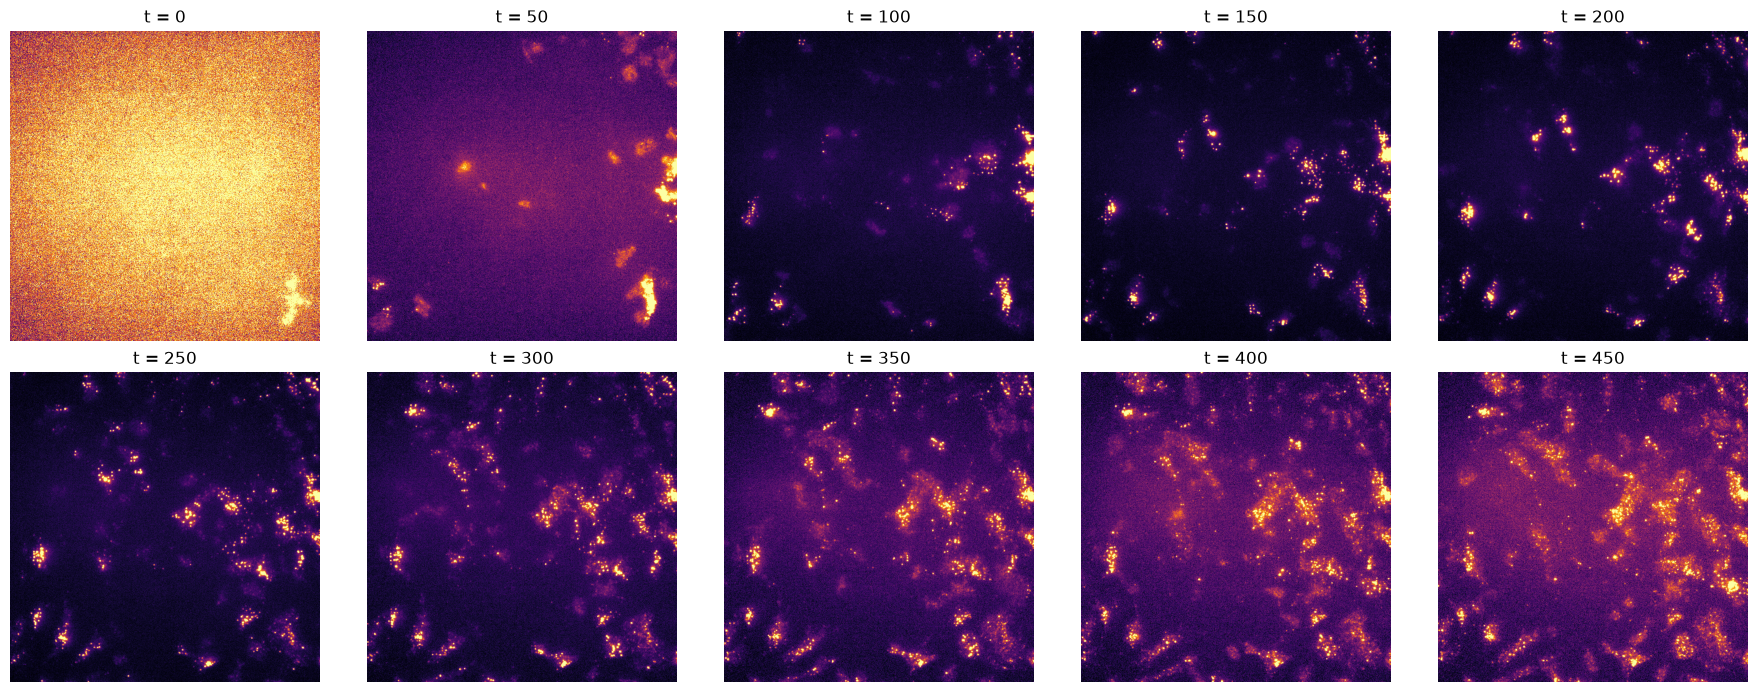

In [43]:
frames = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ax, t in zip(axes.flat, frames):

    ax.imshow(
        merged_ind_norm[t],
        cmap="inferno",
        vmin=0,
        vmax=1
    )

    ax.set_title(f"t = {t}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [82]:
def instance_to_targets(instance_mask, sigma=5):

    foreground = (instance_mask > 0).astype(np.float32)

    centers = np.zeros_like(foreground)

    cell_ids = np.unique(instance_mask)
    cell_ids = cell_ids[cell_ids != 0]

    for cell_id in cell_ids:

        y, x = center_of_mass(
            instance_mask == cell_id
        )

        y = int(round(y))
        x = int(round(x))

        centers[y, x] = 1.0

    centers = gaussian_filter(
        centers,
        sigma=sigma
    )

    if centers.max() > 0:
        centers /= centers.max()

    return foreground, centers

In [83]:
mask = tifffile.imread(
    "cellpose_training/Mask/20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001minusdark_0100_masks.tif"
)

foreground, centers = instance_to_targets(mask)

In [84]:
def get_temporal_window(movie, t, radius=2):

    frames = []

    for dt in range(-radius, radius + 1):

        index = np.clip(
            t + dt,
            0,
            movie.shape[0] - 1
        )

        frames.append(movie[index])

    return np.stack(frames, axis=0)

In [85]:
x = get_temporal_window(
    merged_ind_norm,
    t=100,
    radius=2
)

print(x.shape)

(5, 600, 600)


In [86]:
import torch
from torch.utils.data import Dataset


class CellDataset(Dataset):

    def __init__(
        self,
        movie,
        annotation_frames,
        annotation_dir,
        radius=2,
        patch_size=256,
        samples_per_frame=100
    ):

        self.movie = movie
        self.frames = annotation_frames
        self.annotation_dir = annotation_dir

        self.radius = radius
        self.patch_size = patch_size
        self.samples_per_frame = samples_per_frame

    def __len__(self):

        return (
            len(self.frames)
            * self.samples_per_frame
        )

    def __getitem__(self, idx):

        # Choose frame
        frame_index = (
            idx // self.samples_per_frame
        )

        t = self.frames[frame_index]

        # Temporal input
        x = get_temporal_window(
            self.movie,
            t,
            self.radius
        )

        # Load mask
        mask = tifffile.imread(
            f"{self.annotation_dir}/frame_{t:03d}.tif"
        )

        foreground, centers = instance_to_targets(mask)

        # Random crop position
        h, w = foreground.shape
        ps = self.patch_size

        y0 = np.random.randint(0, h - ps)
        x0 = np.random.randint(0, w - ps)

        # Crop input
        x = x[
            :,
            y0:y0 + ps,
            x0:x0 + ps
        ]

        foreground = foreground[
            y0:y0 + ps,
            x0:x0 + ps
        ]

        centers = centers[
            y0:y0 + ps,
            x0:x0 + ps
        ]

        # Augmentation
        if np.random.rand() > 0.5:

            x = np.flip(x, axis=2).copy()

            foreground = np.flip(
                foreground,
                axis=1
            ).copy()

            centers = np.flip(
                centers,
                axis=1
            ).copy()

        if np.random.rand() > 0.5:

            x = np.flip(x, axis=1).copy()

            foreground = np.flip(
                foreground,
                axis=0
            ).copy()

            centers = np.flip(
                centers,
                axis=0
            ).copy()

        x = torch.from_numpy(x).float()

        y = torch.from_numpy(
            np.stack([
                foreground,
                centers
            ])
        ).float()

        return x, y

In [87]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [88]:
class SmallUNet(nn.Module):

    def __init__(self, in_channels=5, out_channels=2):

        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, 2, stride=2
        )

        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, 2, stride=2
        )

        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, 2, stride=2
        )

        self.dec1 = DoubleConv(64, 32)

        self.output = nn.Conv2d(
            32,
            out_channels,
            1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        b = self.bottleneck(
            self.pool(e3)
        )

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)

In [89]:
import torch.nn.functional as F


def dice_loss(pred, target, eps=1e-6):

    pred = torch.sigmoid(pred)

    intersection = (pred * target).sum(dim=(1, 2))

    union = (
        pred.sum(dim=(1, 2))
        + target.sum(dim=(1, 2))
    )

    dice = (
        (2 * intersection + eps)
        / (union + eps)
    )

    return 1 - dice.mean()

def loss_function(pred, target):

    foreground_bce = F.binary_cross_entropy_with_logits(
        pred[:, 0],
        target[:, 0]
    )

    foreground_dice = dice_loss(
        pred[:, 0],
        target[:, 0]
    )

    foreground_loss = (
        foreground_bce
        + foreground_dice
    )

    # Convert center prediction to 0–1
    center_pred = torch.sigmoid(pred[:, 1])

    center_loss = F.mse_loss(
        center_pred,
        target[:, 1]
    )

    return foreground_loss + center_loss

device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

model = SmallUNet().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

annotation_frames = [
    10,
    50,
    100,
    150,
    200,
    250,
    300,
    350,
    400,
    450
]

dataset = CellDataset(
    merged_ind_norm,
    annotation_frames,
    "cellpose_training/Cellsegmentation/annotations",
    patch_size=256,
    samples_per_frame=100
)

from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

In [90]:
for epoch in range(50):

    model.train()

    epoch_loss = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = loss_function(
            pred,
            y
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"{epoch_loss / len(loader):.4f}"
    )

Epoch 1: 1.1375
Epoch 2: 0.8473
Epoch 3: 0.7055
Epoch 4: 0.6243
Epoch 5: 0.5593
Epoch 6: 0.5136
Epoch 7: 0.4751
Epoch 8: 0.4442
Epoch 9: 0.4164
Epoch 10: 0.4059
Epoch 11: 0.3758
Epoch 12: 0.3606
Epoch 13: 0.3538
Epoch 14: 0.3388
Epoch 15: 0.3261
Epoch 16: 0.3263
Epoch 17: 0.3119
Epoch 18: 0.3004
Epoch 19: 0.2892
Epoch 20: 0.2888
Epoch 21: 0.2774
Epoch 22: 0.2799
Epoch 23: 0.2711
Epoch 24: 0.2616
Epoch 25: 0.2734
Epoch 26: 0.2564
Epoch 27: 0.2523
Epoch 28: 0.2480
Epoch 29: 0.2579
Epoch 30: 0.2432
Epoch 31: 0.2383
Epoch 32: 0.2357
Epoch 33: 0.2383
Epoch 34: 0.2328
Epoch 35: 0.2258
Epoch 36: 0.2304
Epoch 37: 0.2266
Epoch 38: 0.2198
Epoch 39: 0.2181
Epoch 40: 0.2182
Epoch 41: 0.2118
Epoch 42: 0.2143
Epoch 43: 0.2150
Epoch 44: 0.2117
Epoch 45: 0.2082
Epoch 46: 0.2093
Epoch 47: 0.2042
Epoch 48: 0.2140
Epoch 49: 0.1949
Epoch 50: 0.1904


In [91]:
model.eval()

t = 300

x = get_temporal_window(
    merged_ind_norm,
    t,
    radius=2
)

x = torch.from_numpy(
    x[None]
).float().to(device)

with torch.no_grad():

    pred = model(x)

pred = torch.sigmoid(pred)

foreground = pred[0, 0].cpu().numpy()
centers = pred[0, 1].cpu().numpy()

In [92]:
from scipy.ndimage import label
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy.ndimage import distance_transform_edt

cell_mask = foreground > 0.5

# find centers
coordinates = peak_local_max(
    centers,
    min_distance=20,
    threshold_abs=0.3
)

markers = np.zeros_like(
    cell_mask,
    dtype=np.int32
)

for i, (y, x) in enumerate(coordinates, start=1):

    markers[y, x] = i

distance = distance_transform_edt(
    cell_mask
)

labels = watershed(
    -distance,
    markers,
    mask=cell_mask
)

In [93]:
labels.max()

np.int32(27)

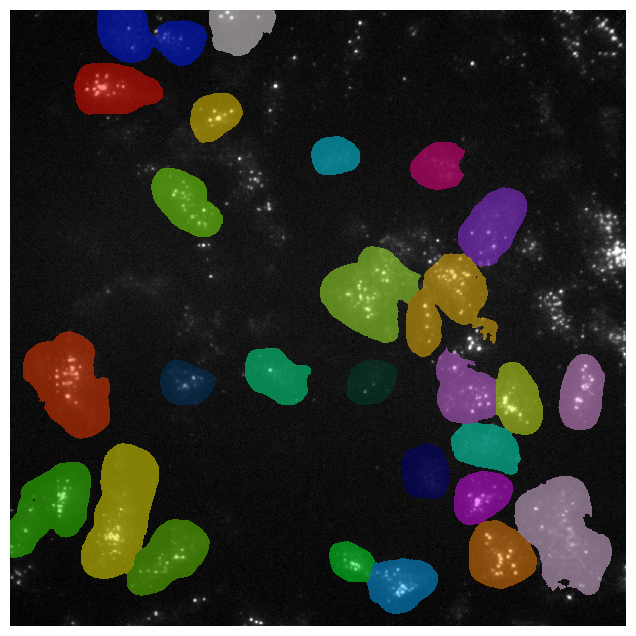

In [94]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Original image
plt.imshow(
    merged_ind_norm[t],
    cmap="gray"
)

# Make background transparent
labels_masked = np.ma.masked_where(
    labels == 0,
    labels
)

# Overlay cells
plt.imshow(
    labels_masked,
    cmap='gist_ncar',
    alpha=0.5,
    interpolation="none"
)

plt.axis("off")
plt.show()